
# Машинное обучение, DS-поток
## Задание ML.12

### Embeddings. Word2Vec. Conv1D

**Правила:**

* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания все участники списывания будут сдавать устный зачет.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Для выполнения задания используйте этот ноутбук в качестве основы, **не исправляйте и не удаляйте условия!** Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* В каждой задаче не забывайте делать **пояснения и выводы**.

**Правила оформления теоретических задач:**

* Решения необходимо прислать в виде $\LaTeX$ в markdown-ячейках.
* В решениях поясняйте, чем вы пользуетесь, хотя бы кратко. Например, если пользуетесь независимостью, то достаточно подписи вида "*X и Y незав.*"
* Решение, в котором есть только ответ, и отсутствуют вычисления, оценивается в 0 баллов.




In [ ]:
# Bot check

# HW_ID: ds_ml12
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

### Ссылки на использование ИИ

Если при решении задач использовался ИИ, укажи здесь публичные ссылки на все чаты с ИИ и поясни, для каких целей он применялся. Обрати внимание на <a href="https://thetahat.ru/courses/ai-rules" target="_top">правила</a>.

**Задача 1**
1. ссылка
    - для чего использована
    - для чего использована
2. ссылка
    - для чего использована

---
### Задача 1
В данном домашнем задании вам предлагается проанализировать и улучшить модель для задачи `Sentiment Analysis`, которую вы обучали на семинаре.

Предлагается выполнить следующие пункты:


1. **(20 баллов)** Примените стемминг или лемматизацию к датасету. Как поменялось качество?

2. **(20 баллов)** Попробуйте изменить размерность эмбеддинга на сильно большую и сильно меньшую. В качестве размеров эмбеддингов можно взять 30 и 200. Как меняется качество модели? Какая модель более склонна к переобучению и почему?

3. **(20 баллов)** Посмотрите на обученнные вами эмбеддинги у модели с маленьким размером эмбеддинга из предыдущего пункта. Для нескольких слов найдите похожие на него по косинусной мере близости.

5. **(20 баллов)** Попробуйте рассмотреть фильтры меньших размеров.
 * Рассмотрите фильтры размеров 1, 2, 3
 * Рассмотрите фильтры размеров 1, 2

 Сильно ли меняется качество модели для данной задачи? Почему?

5. **(20 баллов)** Как можно заметить, у нас не сильно большая тренировочная выборка. Попробуйте сделать аугментацию текста.

  Один из вариантов: заменять слово на синоним с какой-то вероятностью $p$. То есть с вероятностью $p$ каждое слово будет заменено на некоторый его синоним, а с вероятностью $1 - p$ слово останется как есть.


Для простоты анализа результатов стоит не применять сразу несколько улучшений, а делать их отдельно. В каждом выполняемом пункте **постройте кривую лосса** как для трейна, так и для валидации.

In [1]:
# Устанавливаем библиотеки с фиксированными версиями для воспроизводимости
# (важно при обучении моделей — API разных версий может отличаться)
!pip install -U \
    nltk==3.8.1 \
    gensim==4.3.2 \
    torch==2.5.0 \
    torchdata==0.8.0 \
    datasets \
    spacy==3.8.2 \
    scipy==1.11.4 \
    scikit-learn \
    hf_xet --user

# Скачиваем предобученную языковую модель spaCy для токенизации английского текста
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 22.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 906.4/906.4 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 94.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.8/31.8 MB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 72.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 37.6 MB/s eta 0:

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 105.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
import numpy as np
import random
import time

from tqdm import tqdm
from IPython.display import clear_output
from matplotlib import pyplot as plt

import gensim
import nltk
import spacy

from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import wordnet
from nltk.stem import PorterStemmer, WordNetLemmatizer

from collections import Counter, OrderedDict
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import random_split, DataLoader
from torch.nn.utils.rnn import pad_sequence

from datasets import load_dataset

nltk.download("punkt") # для токенизации текстов и работы с пунктуацией
nltk.download("wordnet") # для графа зависимостей между словами
import string

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...


Зафиксируем random seed для воспроизводимости результатов

In [3]:
SEED = 1234
random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

Скачаем данные, представив их в виде трейна, валидации и теста.

In [4]:
raw_dataset = load_dataset("imdb")

train_dataset = raw_dataset['train']
test_dataset = raw_dataset['test']

# размер. обуч выборки
num_train = int(len(train_dataset) * 0.9)

train_data, valid_data = random_split(
    train_dataset,
    [num_train, len(train_dataset) - num_train],
    torch.Generator().manual_seed(SEED)
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

По желанию используйте вспомогательные функции с семинара. Вы можете их переписать и(или) дополнить, если потребуется.

In [5]:
print(train_data[0])

{'text': 'Along with "King of the Rocket Men", this was still being repeated on BBC TV in the early to mid eighties. If I was loading up a time capsule of this period both these series would definitely go in.<br /><br />Someone watching it for the first time will think it is silly but this is one of the best examples of the "Serials". Don Del Oro will make you laugh (When I was little my nickname for him was Mr Dustbin head) and it was funny upon being shot at he says "Your bullets can\'t harm me" then he stumbles back, seemingly less than happy. I also like the way he dispenses with Sebastian in the first episode.<br /><br />I watched this again because I had good memories of it from years back, there are some good stunts and good music, it has the ingredients you expect including water,rockfalls,runaway carts... Apart from the first episode(with Ralph Faulkner)the swordplay wasn\'t nearly as good as I remembered it, and yes it features the inevitable "flashback" episode! It gets 8 ou

In [6]:
nlp = spacy.load("en_core_web_sm")
# токенизатор — возвращает список токенов (строк) в нижнем регистре
def tokenizer_spacy(text):
    return [t.text for t in nlp(text)]

In [ ]:
train_tokenized = [tokenizer_spacy(item['text']) for item in tqdm(train_data)]
valid_tokenized = [tokenizer_spacy(item['text']) for item in tqdm(valid_data)]
test_tokenized = [tokenizer_spacy(item['text']) for item in tqdm(test_dataset)]


In [7]:
train_labels_raw = [item['label'] for item in train_data]
valid_labels_raw = [item['label'] for item in valid_data]
test_labels_raw = [item['label'] for item in test_dataset]

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
# np.save("/content/drive/MyDrive/DScource/ML12/train_tokenized.npy", np.array(train_tokenized, dtype=object))
# np.save("/content/drive/MyDrive/DScource/ML12/valid_tokenized.npy", np.array(valid_tokenized, dtype=object))
# np.save("/content/drive/MyDrive/DScource/ML12/test_tokenized.npy", np.array(test_tokenized, dtype=object))
train_tokenized = np.load("/content/drive/MyDrive/train_tokenized.npy", allow_pickle=True)
valid_tokenized = np.load("/content/drive/MyDrive/valid_tokenized.npy", allow_pickle=True)
test_tokenized = np.load("/content/drive/MyDrive/test_tokenized.npy", allow_pickle=True)

**1.** **Предобработка данных**

Примените стемминг или лемматизацию к обучающему, валидационному и тестовому датасету.


In [10]:
ps = PorterStemmer()
train_stemmed = []
valid_stemmed = []
test_stemmed = []
for tokens in tqdm(train_tokenized):
  train_stemmed.append([ps.stem(token) for token in tokens])
for tokens in tqdm(valid_tokenized):
  valid_stemmed.append([ps.stem(token) for token in tokens])
for tokens in tqdm(test_tokenized):
  test_stemmed.append([ps.stem(token) for token in tokens])

100%|██████████| 25000/25000 [01:16<00:00, 325.76it/s]


Ограничьте словарь для модели, убрав наименее частые слова. Это сделает обучение модели менее ресурсозатратным, а также позволит избавиться от потенциальных слов с орфографическими ошибками.

In [11]:
nltk.download("stopwords")
punctuation = string.punctuation

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [12]:
MAX_VOCAB_SIZE = 25000
counter = Counter()

# удалим стоп-слова и пунктуацию
stop_words = nltk.corpus.stopwords.words("english")
for tokens in tqdm(train_stemmed):
    counter.update([t.lower() for t in tokens if t.lower() not in stop_words and t not in punctuation])

# удалим редкие слова
most_common = counter.most_common(MAX_VOCAB_SIZE)
ordered_dict = OrderedDict(most_common)

# Соберём словарь
specials = ["<unk>", "<pad>"]
itos = specials + [tok for tok in ordered_dict.keys()]
stoi = {tok: idx for idx, tok in enumerate(itos)}

UNK_IDX = stoi["<unk>"]
PAD_IDX = stoi["<pad>"]

print(f"Размер словаря (с учётом спецтокенов): {len(itos)}")

100%|██████████| 22500/22500 [00:11<00:00, 1918.86it/s]


Размер словаря (с учётом спецтокенов): 25002


In [13]:
def encode_tokens(tokens):
    return [stoi.get(t.lower(), UNK_IDX) for t in tokens]
train_encoded = [encode_tokens(tokens) for tokens in train_stemmed]
test_encoded = [encode_tokens(tokens) for tokens in test_stemmed]
valid_encoded = [encode_tokens(tokens) for tokens in valid_stemmed]

Создайте итератор для обучающего, валидационного и тестового датасетов. Будет полезно обратить внимание на типы датасетов в Pytorch: [ссылка](https://pytorch.org/docs/stable/data.html#dataset-types).

In [14]:
BATCH_SIZE = 64
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def pad_collate(batch):
    texts, labels = zip(*batch)
    texts_tensors = [torch.LongTensor(t).to(DEVICE) for t in texts]
    labels_tensors = torch.FloatTensor(labels).to(DEVICE)
    texts_padded = pad_sequence(texts_tensors, batch_first=True, padding_value=PAD_IDX)
    return texts_padded, labels_tensors

In [ ]:
train_loader = DataLoader(list(zip(train_encoded, train_labels_raw)), batch_size=BATCH_SIZE, shuffle=True, collate_fn=pad_collate)
valid_loader = DataLoader(list(zip(valid_encoded, valid_labels_raw)), batch_size=BATCH_SIZE, shuffle=False, collate_fn=pad_collate)
test_loader = DataLoader(list(zip(test_encoded, test_labels_raw)), batch_size=BATCH_SIZE, shuffle=False, collate_fn=pad_collate)

Зададим модель, аналогичную той, что была на семинаре.

In [15]:
class CNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, n_filters, filter_sizes, output_dim,
                 dropout, pad_idx):
        """
        Функция инициализации модели.

        Параметры.
        1) vocab_size — размер словаря,
        2) embedding_dim — размерность векторов-эмбеддингов,
        3) n_filters — количество свёрточных фильтров на каждом слое,
        4) filter_sizes — количество свёрточных слоёв,
        5) output_dim — размер выхода модели,
        6) dropout — вещественное число от 0 до 1, вероятность отключения нейронов,
        7) pad_idx — токен для паддинга.
        """

        super().__init__()
        # эмбеддинг-слой
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx = pad_idx)
        # свёрточные слои
        self.convs = nn.ModuleList([
          nn.Conv1d(
              in_channels=embedding_dim, out_channels=n_filters,
              kernel_size=fs,
          ) for fs in filter_sizes
        ])
        # полносвязный слой для получение выхода модели
        self.fc = nn.Linear(len(filter_sizes) * n_filters, output_dim)
        # dropout для регуляризации сети
        self.dropout = nn.Dropout(dropout)

    def forward(self, text):
        """ Функция для получения выходов сети по текстам """

        #text.dim = [batch size, sent len]
        #embedded.dim = [batch size, sent len, emb dim]
        embedded = self.embedding(text)

        #embedded.dim = [batch size, emb dim, sent len]
        embedded = embedded.permute(0, 2, 1)

        #conved_n.dim = [batch size, n_filters, sent len - filter_sizes[n] + 1]
        conved = [F.relu(conv(embedded)) for conv in self.convs]

        #pooled_n.dim = [batch size, n_filters]
        pooled = [F.max_pool1d(conv, conv.shape[2]).squeeze(2) for conv in conved]

        #cat.dim = [batch size, n_filters * len(filter_sizes)]
        cat = self.dropout(torch.cat(pooled, dim = 1))

        return self.fc(cat)

Проинициализируйте и обучите модель.

In [17]:
INPUT_DIM = len(itos)    # размер словаря
EMBEDDING_DIM = 100       # размерность векторов-эмбеддингов
N_FILTERS = 100           # количество свёрточных фильтров
FILTER_SIZES = [3, 4, 5]  # размеры фильтров на каждом уровне
OUTPUT_DIM = 1            # размерность выхода (сеть выдаёт вероятность для одного класса)
DROPOUT = 0.5             # вероятность dropout
PAD_IDX = UNK_IDX         # id токена для паддинга

model = CNN(INPUT_DIM, EMBEDDING_DIM, N_FILTERS, FILTER_SIZES, OUTPUT_DIM, DROPOUT, PAD_IDX)

In [18]:
def count_parameters(model):
    """ Подсчёт числа параметров модели """
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Модель имеет {count_parameters(model):,} обучаемых параметров")
print(f"Слой ембеддингов: {count_parameters(model.embedding):,} обучаемых параметров")
print(f"Слои свёртки: {count_parameters(model.convs):,} обучаемых параметров")
print(f"Линейный слой: {count_parameters(model.fc):,} обучаемых параметров")
model.eval()

Модель имеет 2,620,801 обучаемых параметров
Слой ембеддингов: 2,500,200 обучаемых параметров
Слои свёртки: 120,300 обучаемых параметров
Линейный слой: 301 обучаемых параметров


CNN(
  (embedding): Embedding(25002, 100, padding_idx=0)
  (convs): ModuleList(
    (0): Conv1d(100, 100, kernel_size=(3,), stride=(1,))
    (1): Conv1d(100, 100, kernel_size=(4,), stride=(1,))
    (2): Conv1d(100, 100, kernel_size=(5,), stride=(1,))
  )
  (fc): Linear(in_features=300, out_features=1, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

In [19]:
def binary_accuracy(preds, y):
    """
    Возвращает точность модели.

    Параметры.
    1) preds — предсказания модели,
    2) y — истинные метки классов.
    """

    # округляет предсказания до ближайшего integer
    rounded_preds = torch.round(torch.sigmoid(preds))
    correct = (rounded_preds == y).float()
    acc = correct.sum() / len(correct)
    return acc

In [20]:
def train(model, iterator, optimizer, criterion, loss_history):
    """
    Функция для обучения модели на обучающем датасете и подсчёта
    её точности.

    Параметры.
    1) model — модель,
    2) iterator — итератор обучающего датасета,
    3) optimizer — класс метода оптимизации,
    4) criterion — функция потерь.
    """

    epoch_loss = 0
    epoch_acc = 0
    model.train()

    for batch_id, batch in enumerate(iterator):
        # чтобы градиент не накапливался, его нужно обнулить
        optimizer.zero_grad()
        # получим предсказания модели
        texts, labels = batch
        predictions = model(texts).squeeze(1)
        loss = criterion(predictions, labels)
        acc = binary_accuracy(predictions, labels)

        # сделаем back-propagation для подсчёта градиентов
        loss.backward()
        # выполним шаг оптимизатора
        optimizer.step()
        # обновим метрики
        epoch_loss += loss.item()
        epoch_acc += acc.item()
        loss_history.append(loss.item())

    return epoch_loss / len(iterator), epoch_acc / len(iterator)

In [21]:
def evaluate(model, iterator, criterion, loss_history=None):
    """
    Функция для применения модели на валидационном/тестовом датасете и подсчёта
    её точности.

    Параметры.
    1) model — модель,
    2) iterator — итератор датасета,
    3) criterion — функция потерь.
    """

    epoch_loss = 0
    epoch_acc = 0

    model.eval()

    with torch.no_grad(): # отключим подсчёт градиентов на валидации
        for batch_id, batch in enumerate(iterator):
            inp, label = batch

            # получим предсказания
            predictions = model(inp).squeeze(1)
            # посчитаем метрики
            loss = criterion(predictions, label)
            acc = binary_accuracy(predictions, label)
            # обновим метрики
            epoch_loss += loss.item()
            epoch_acc += acc.item()
            if loss_history is not None:
                loss_history.append(loss.item())

    return epoch_loss / len(iterator), epoch_acc / len(iterator)

In [22]:
def epoch_time(start_time, end_time):
    """
    Функция для подсчёта времени работы одной эпохи.

    Параметры.
    1) start_time — время начала запуска,
    2) end_time — время завершения работы эпохи.
    """

    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

In [ ]:
optimizer = torch.optim.Adam(model.parameters())
criterion = nn.BCEWithLogitsLoss()
model = model.to(DEVICE)
criterion = criterion.to(DEVICE)

In [23]:
def training_loop(model_instance, n_epochs=10):
    """
    Функция для обучения нейронной сети.

    Параметры.
    1) model_instance — обучаемая модель,
    2) n_epochs — количество эпох.
    """

    best_valid_loss = float('inf')
    loss_history = []
    val_loss_history = []
    acc_history = []
    val_acc_history = []

    for epoch in range(n_epochs):
        start_time = time.time()
        # Обучим одну эпоху на обучающем датасете
        train_loss, train_acc = train(model_instance, train_loader, optimizer, criterion, loss_history)
        acc_history.append(train_acc)

        # Оценим точность модели на тестовом датасете
        valid_loss, valid_acc = evaluate(model_instance, valid_loader, criterion, val_loss_history)
        val_acc_history.append(valid_acc)

        # Посчитаем время работы одной эпохи
        end_time = time.time()
        epoch_mins, epoch_secs = epoch_time(start_time, end_time)
        # Отобразим графики loss'ов
        clear_output(True)
        plt.figure(figsize=(18, 6))
        plt.subplot(1, 3, 1)
        plt.plot(loss_history)
        plt.title("Train Loss")
        plt.xlabel("Номер батча")
        plt.subplot(1, 3, 2)
        plt.plot(val_loss_history, color="tab:orange")
        plt.title("Valid Loss")
        plt.xlabel("Номер батча")
        # Если значение функции потерь улучшилось, сохраним параметры модели
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            torch.save(model_instance.state_dict(), 'model_checkpoint.pt')

        # Отрисуем значение точности от эпохи
        plt.subplot(1, 3, 3)
        plt.plot(acc_history, label="Train")
        plt.plot(val_acc_history, label="Valid")
        plt.legend()
        plt.title("Accuracy")
        plt.xlabel("Номер эпохи")
        plt.show()

        print(f"Номер эпохи: {epoch+1:02} | Время обучения эпохи: {epoch_mins}m {epoch_secs}s")

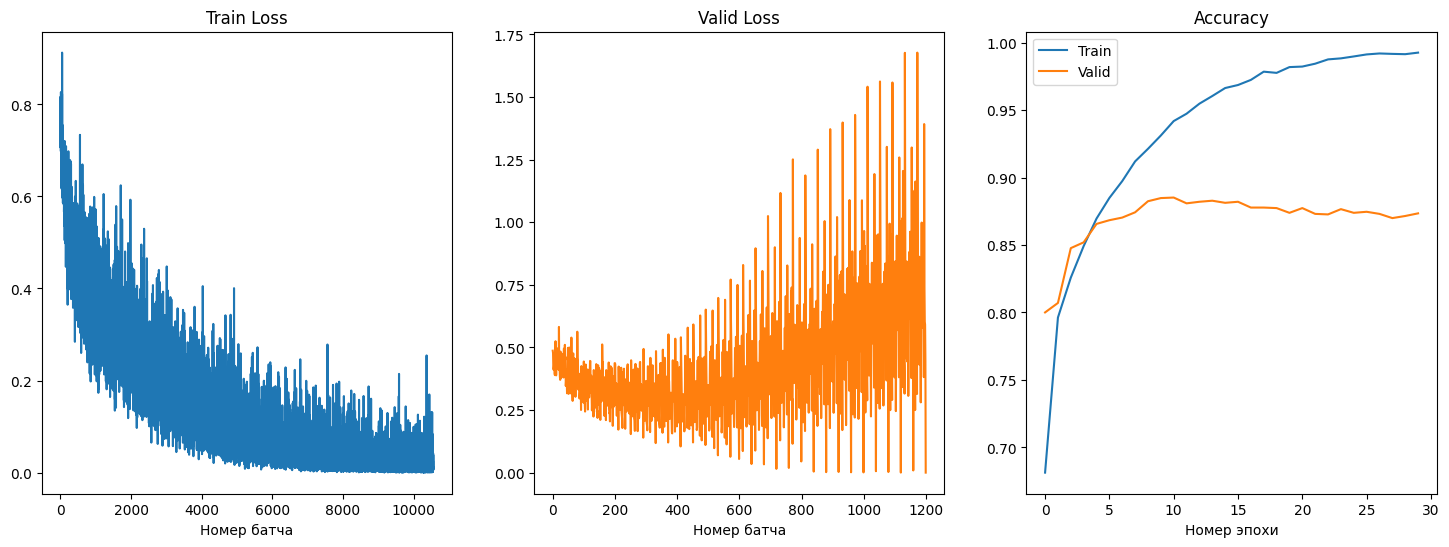

Номер эпохи: 30 | Время обучения эпохи: 0m 12s


In [ ]:
training_loop(model, 30)

Посчитайте качество модели на тестовой выборке.

In [ ]:
model.load_state_dict(torch.load("model_checkpoint.pt"))
test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"Test Loss: {test_loss:.3f} | Test Acc: {test_acc*100:.2f}%")

/tmp/ipython-input-4154245667.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("model_checkpoint.pt"))


Test Loss: 0.302 | Test Acc: 87.58%


**2.** **Изменение размера эмбеддинга**

Уменьшите размер эмбеддингов до 30. Как поменялось качество модели?

*Замечание.* Если в предыдущем пункте вы перезаписали датасеты, применив к ним стемминг или лемматизацию, то их нужно скачать заново. Обратите внимание также на используемый словарь.

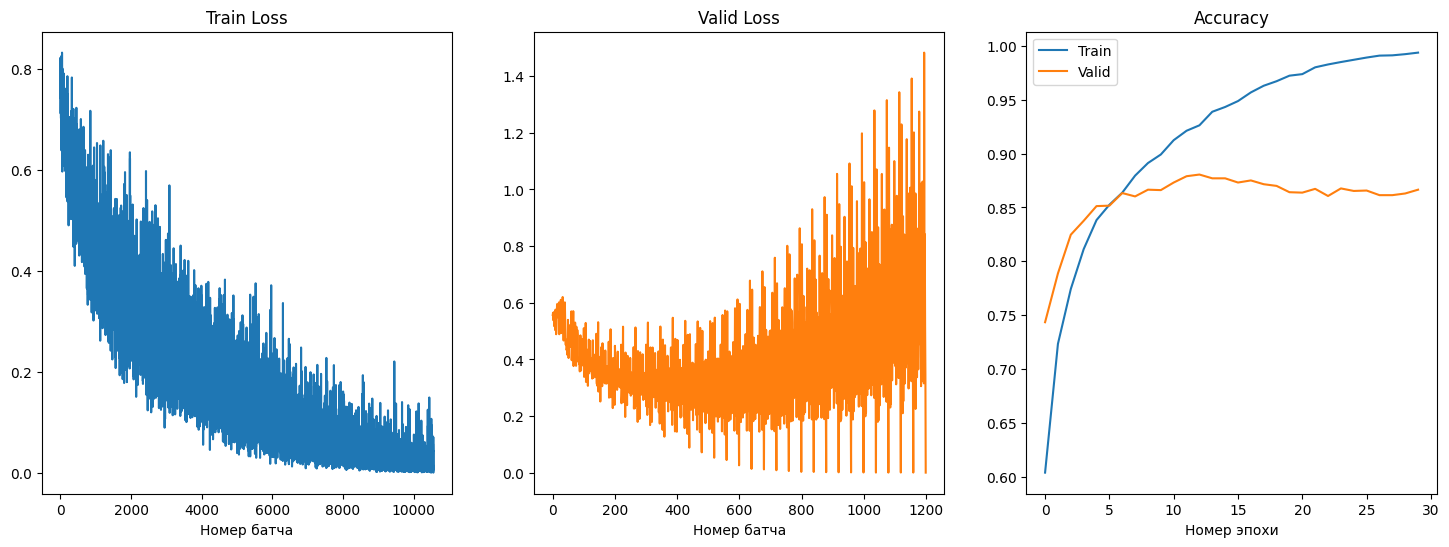

Номер эпохи: 30 | Время обучения эпохи: 0m 7s


In [ ]:
INPUT_DIM = len(itos)    # размер словаря
EMBEDDING_DIM = 30     # размерность векторов-эмбеддингов
N_FILTERS = 100           # количество свёрточных фильтров
FILTER_SIZES = [3, 4, 5]  # размеры фильтров на каждом уровне
OUTPUT_DIM = 1            # размерность выхода (сеть выдаёт вероятность для одного класса)
DROPOUT = 0.5             # вероятность dropout
PAD_IDX = UNK_IDX         # id токена для паддинга

model = CNN(INPUT_DIM, EMBEDDING_DIM, N_FILTERS, FILTER_SIZES, OUTPUT_DIM, DROPOUT, PAD_IDX)

optimizer = torch.optim.Adam(model.parameters())
criterion = nn.BCEWithLogitsLoss()
model = model.to(DEVICE)
criterion = criterion.to(DEVICE)

training_loop(model, 30)

In [ ]:
test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"Test Loss: {test_loss:.3f} | Test Acc: {test_acc*100:.2f}%")

Test Loss: 0.707 | Test Acc: 83.67%


Теперь  увеличьте размер эмбеддингов до 200. Как поменялось качество модели в сравнении с предыдущей? Какая модель более склонна к переобучению и почему?

Сделайте выводы.

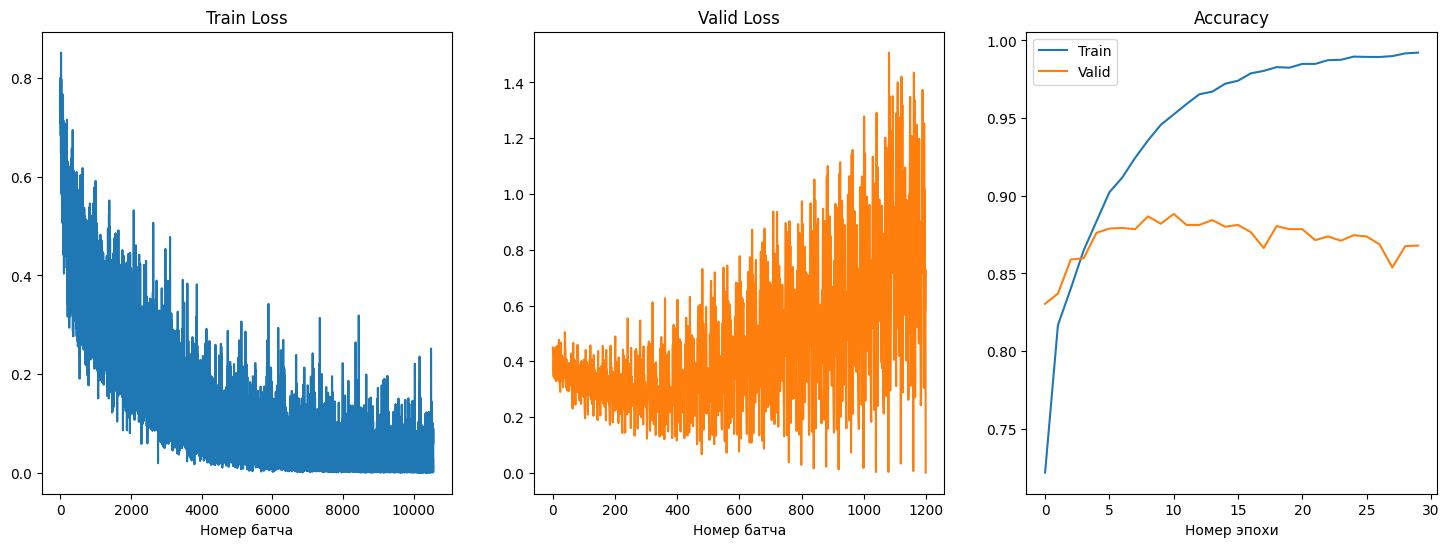

Номер эпохи: 30 | Время обучения эпохи: 0m 21s


In [ ]:
INPUT_DIM = len(itos)    # размер словаря
EMBEDDING_DIM = 200      # размерность векторов-эмбеддингов
N_FILTERS = 100           # количество свёрточных фильтров
FILTER_SIZES = [3, 4, 5]  # размеры фильтров на каждом уровне
OUTPUT_DIM = 1            # размерность выхода (сеть выдаёт вероятность для одного класса)
DROPOUT = 0.5             # вероятность dropout
PAD_IDX = UNK_IDX         # id токена для паддинга

model = CNN(INPUT_DIM, EMBEDDING_DIM, N_FILTERS, FILTER_SIZES, OUTPUT_DIM, DROPOUT, PAD_IDX)

optimizer = torch.optim.Adam(model.parameters())
criterion = nn.BCEWithLogitsLoss()
model = model.to(DEVICE)
criterion = criterion.to(DEVICE)

training_loop(model, 30)

In [ ]:
test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"Test Loss: {test_loss:.3f} | Test Acc: {test_acc*100:.2f}%")

Test Loss: 0.940 | Test Acc: 83.91%


Видим, что как при увеличении размеров ембеддинга, так и при его уменьшении, качество на тесте упало, то есть нужно искать некоторый оптимальный гиперпараметр: если размерность слишком мала, то модель не может уловить все закономерности, если слишком велика, то модель более склонна к переобучению, нужно больше данных. Переобучение во всех случаях небольшое, однако при размере эмбеддинга 200 качество более шумное

**3.** **Нахождение близких слов по эмбеддингам.**

Напишите функцию, считающую [cosine similarity](https://en.wikipedia.org/wiki/Cosine_similarity) между двумя векторами. Именно косинусная мера близости очень часто используется в качестве меры схожести двух эмбеддинг-векторов.

In [ ]:
def cosine_similarity(a, b):
    a = a.detach().cpu().numpy()
    b = b.detach().cpu().numpy()
    return (a @ b) / (np.linalg.norm(a) * np.linalg.norm(b))

Напишите функцию, которая принимает на вход слово word и $k$ и возвращает $k$ наиболее похожих на word слов.

Эмбеддинги для каждого слова должны быть получены с помощью матрицы эмбеддингов из Embedding слоя вашей модели. В качестве модели возьмите модель из предыдущего пункта с маленьким размером эмбеддинга.



In [ ]:
INPUT_DIM = len(itos)    # размер словаря
EMBEDDING_DIM = 200       # размерность векторов-эмбеддингов
N_FILTERS = 100           # количество свёрточных фильтров
FILTER_SIZES = [3, 4, 5]  # размеры фильтров на каждом уровне
OUTPUT_DIM = 1            # размерность выхода (сеть выдаёт вероятность для одного класса)
DROPOUT = 0.5             # вероятность dropout
PAD_IDX = UNK_IDX         # id токена для паддинга

model = CNN(INPUT_DIM, EMBEDDING_DIM, N_FILTERS, FILTER_SIZES, OUTPUT_DIM, DROPOUT, PAD_IDX)
state_dict = torch.load("/content/model_checkpoint.pt", map_location=DEVICE)
model.load_state_dict(state_dict)

model = model.to(DEVICE)
model.eval()

In [ ]:
def find_most_similar(word, k=5):
    word_idx = stoi.get(word, UNK_IDX)
    word_emb = model.embedding(torch.tensor(word_idx).to(DEVICE))
    sims = []

    for new_word in tqdm(itos[1:]):
        new_idx = stoi.get(new_word, UNK_IDX)
        new_emb = model.embedding(torch.tensor(new_idx).to(DEVICE))
        sims.append(float(cosine_similarity(word_emb, new_emb)))

    args = np.argsort(sims)
    ans = []

    for i in args[::-1]:
        if i == word_idx:
            continue
        ans.append(itos[i])
        if len(ans) >= k:
            break

    return ans

Выберите несколько слов из словаря и посмотрите на их ближайшие по эмбеддингу 5 слов.

In [ ]:
find_most_similar('great', 5)

100%|██████████| 25001/25001 [00:04<00:00, 6107.06it/s]


['bad', 'bardot', 'frwl', 'partial', 'nutti']

In [ ]:
find_most_similar('drama', 5)

100%|██████████| 25001/25001 [00:04<00:00, 5316.34it/s]


['experi', 'maxx', 'screen.<br', 'assembl', 'oaf']

In [ ]:
find_most_similar('wife', 5)

100%|██████████| 25001/25001 [00:04<00:00, 5921.93it/s]


['later', 'pirovitch', 'mccormick', 'lordi', '17']

**4.** **Эксперементы со свёртками.**

Обучите модель с фильтрами меньших размеров: 1, 2 и 3. Измерьте ее качество и подумайте как наилучшим образом изобразить результаты.

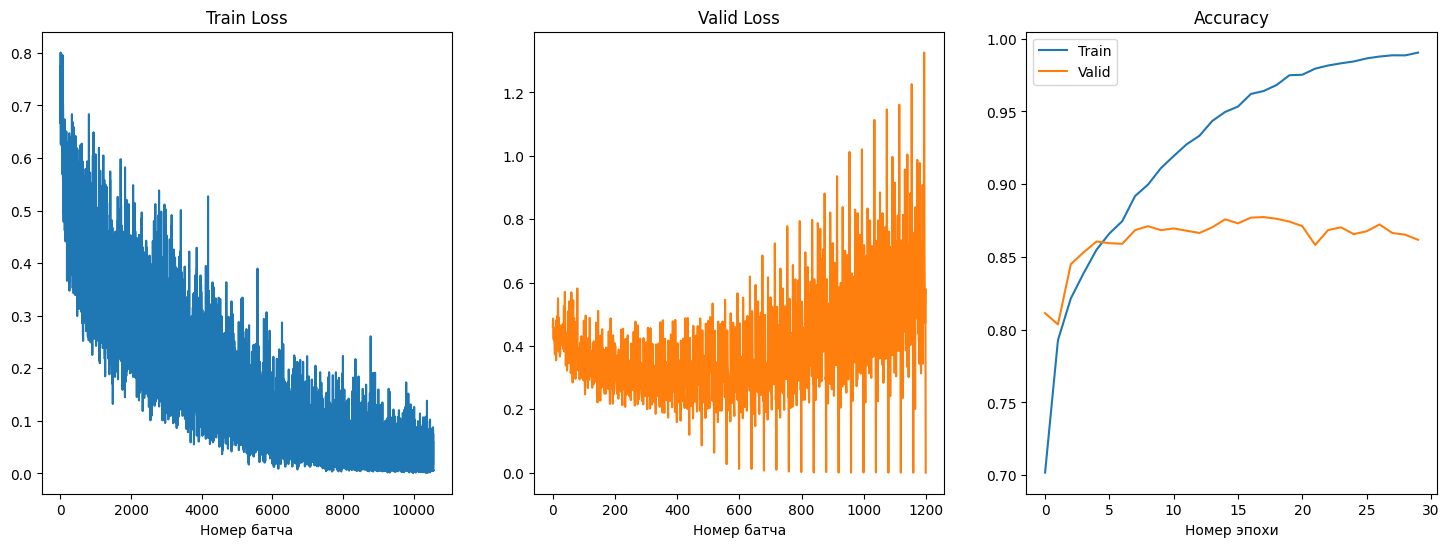

Номер эпохи: 30 | Время обучения эпохи: 0m 9s


In [ ]:
INPUT_DIM = len(itos)    # размер словаря
EMBEDDING_DIM = 100      # размерность векторов-эмбеддингов
N_FILTERS = 100           # количество свёрточных фильтров
FILTER_SIZES = [1, 2, 3]  # размеры фильтров на каждом уровне
OUTPUT_DIM = 1            # размерность выхода (сеть выдаёт вероятность для одного класса)
DROPOUT = 0.5             # вероятность dropout
PAD_IDX = UNK_IDX         # id токена для паддинга

model = CNN(INPUT_DIM, EMBEDDING_DIM, N_FILTERS, FILTER_SIZES, OUTPUT_DIM, DROPOUT, PAD_IDX)

optimizer = torch.optim.Adam(model.parameters())
criterion = nn.BCEWithLogitsLoss()
model = model.to(DEVICE)
criterion = criterion.to(DEVICE)

training_loop(model, 30)

In [ ]:
test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"Test Loss: {test_loss:.3f} | Test Acc: {test_acc*100:.2f}%")

Test Loss: 0.786 | Test Acc: 82.87%


Теперь рассмотрим лишь фильтры размера 1 и 2.

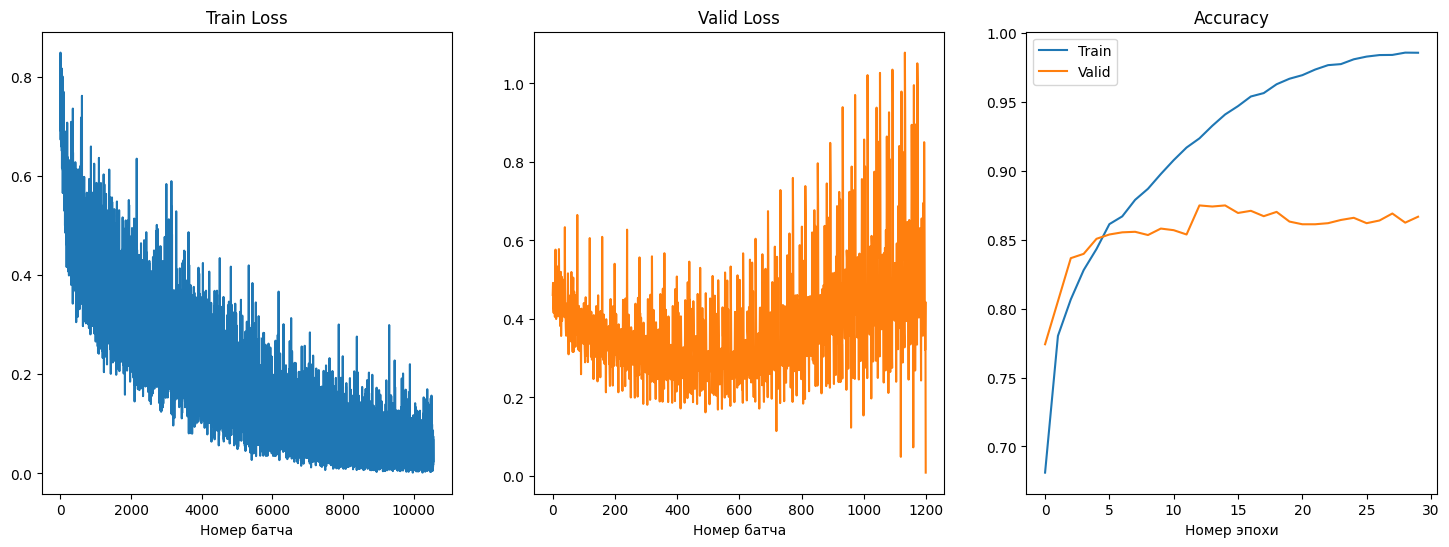

Номер эпохи: 30 | Время обучения эпохи: 0m 6s


In [ ]:
INPUT_DIM = len(itos)     # размер словаря
EMBEDDING_DIM = 100       # размерность векторов-эмбеддингов
N_FILTERS = 100           # количество свёрточных фильтров
FILTER_SIZES = [1, 2]     # размеры фильтров на каждом уровне
OUTPUT_DIM = 1            # размерность выхода (сеть выдаёт вероятность для одного класса)
DROPOUT = 0.5             # вероятность dropout
PAD_IDX = UNK_IDX         # id токена для паддинга

model = CNN(INPUT_DIM, EMBEDDING_DIM, N_FILTERS, FILTER_SIZES, OUTPUT_DIM, DROPOUT, PAD_IDX)

optimizer = torch.optim.Adam(model.parameters())
criterion = nn.BCEWithLogitsLoss()
model = model.to(DEVICE)
criterion = criterion.to(DEVICE)

training_loop(model, 30)

In [ ]:
test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"Test Loss: {test_loss:.3f} | Test Acc: {test_acc*100:.2f}%")

Test Loss: 0.695 | Test Acc: 83.12%


Сильно ли меняется качество модели для данной задачи? Почему?

Видим, что качество практически не меняется. То есть даже при меньшем количестве конкатенируемых слоёв, причём при отсутствии свёртки с самым большим ядром, всё равно качество не меняется. Это может говорить о том, что контекст в предложениях не так важен, модель больше обращает внимание на конкретные слова: для этого не нужно знать много контекста, например, фильм понравился/ не понравился

**5.** **Аугментация данных.**

Попробуйте сделать аугментацию текста.

Замените слово на синоним с некоторой вероятностью $p$. То есть с вероятностью $p$ каждое слово будет заменено на некоторый его синоним, а с вероятностью $1 - p$ слово останется как есть.

Обучите модель на таких данных и посмотрите на качество.

In [ ]:
def find_synonyms(word):
    ans = []
    for synset in wordnet.synsets(word):
        ans.extend([x for x in synset.lemma_names() if x != word])
    return ans

In [ ]:
syns = find_synonyms("computer")
syn = syns[np.random.randint(len(syns))]
syn

'data_processor'

Дальше нужно написать свой dataset с трансформацией в \__getitem__

In [24]:
class ADataset(torch.utils.data.Dataset):
    def __init__(self, data_tokenized, labels, probability=0):
        self.data_tokenized = data_tokenized
        self.labels = labels
        self.p = probability

    def __len__(self):
        return len(self.labels)

    def _getsynonimp(self, word):
        if np.random.binomial(1, self.p):
            syns = []
            for synset in wordnet.synsets(word):
                syns.extend([x for x in synset.lemma_names() if x != word])
            if syns:
                return syns[np.random.randint(len(syns))]
        return word

    def _encode_tokens(self, tokens):
        return [stoi.get(t.lower(), UNK_IDX) for t in tokens]

    def __getitem__(self, idx):
        text_tokenized = self.data_tokenized[idx].copy()
        label = self.labels[idx]

        text_tokenized = [self._getsynonimp(word) for word in text_tokenized]

        return self._encode_tokens(text_tokenized), label

In [29]:
train_dataset = ADataset(train_stemmed, train_labels_raw, 0.01)
valid_dataset = ADataset(valid_stemmed, valid_labels_raw)
test_dataset = ADataset(test_stemmed, test_labels_raw)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=pad_collate)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=pad_collate)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=pad_collate)

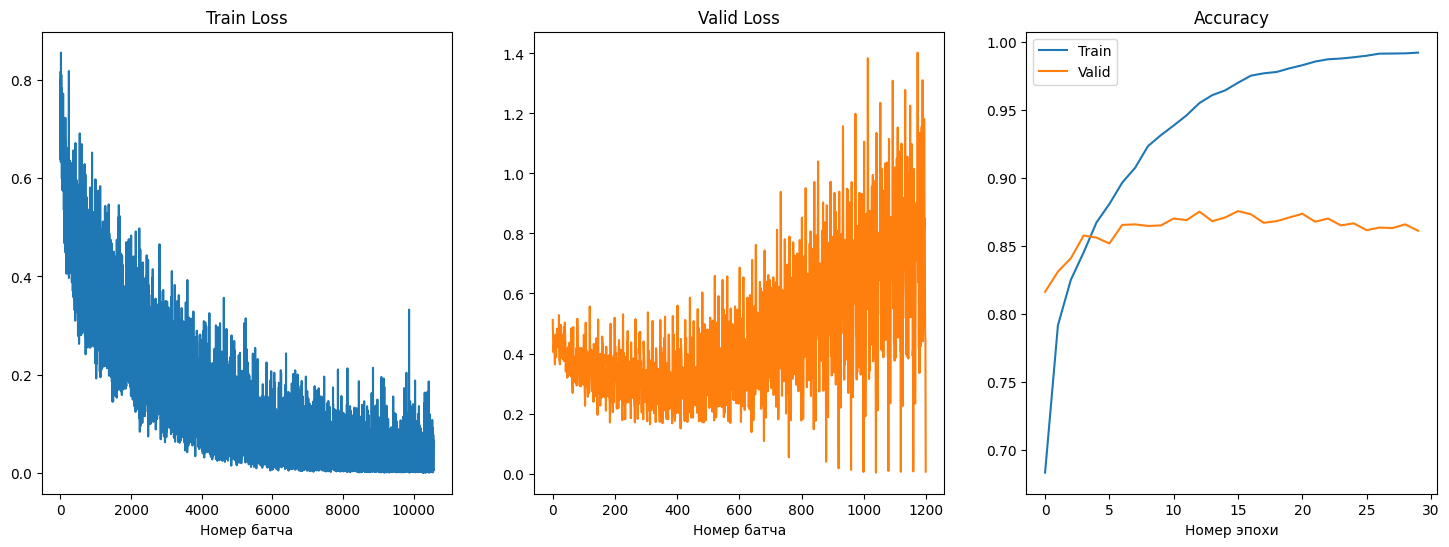

Номер эпохи: 30 | Время обучения эпохи: 0m 21s


In [30]:
INPUT_DIM = len(itos)    # размер словаря
EMBEDDING_DIM = 100       # размерность векторов-эмбеддингов
N_FILTERS = 100           # количество свёрточных фильтров
FILTER_SIZES = [3, 4, 5]  # размеры фильтров на каждом уровне
OUTPUT_DIM = 1            # размерность выхода (сеть выдаёт вероятность для одного класса)
DROPOUT = 0.5             # вероятность dropout
PAD_IDX = UNK_IDX         # id токена для паддинга
model = CNN(INPUT_DIM, EMBEDDING_DIM, N_FILTERS, FILTER_SIZES, OUTPUT_DIM, DROPOUT, PAD_IDX)
model = model.to(DEVICE)
optimizer = torch.optim.Adam(model.parameters())
criterion = nn.BCEWithLogitsLoss()
criterion = criterion.to(DEVICE)

training_loop(model, 30)

In [31]:
test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"Test Loss: {test_loss:.3f} | Test Acc: {test_acc*100:.2f}%")

Test Loss: 0.827 | Test Acc: 83.67%


Улучшить качество не получилось, потому что синонимичные слова не всегда есть в нашем словаре, соотвественно часть слов просто поменялись на unknown и затруднили работу модели. Я думаю, что таких больше, чем праильных

**Выводы:** Свёрточные нейронные сети хорошо справляются с определением качества отзыва о фильме, используя встроенный эмбеддинг слов. Для самого эмбиддинга важен размер получаемых векторов. В задачах такого типа не так важен receptive_field. В NLP также есть аугментации: синонимы. В таких грубых задачх хорошо работает стемминг и лемматизация

---
© 2025 команда <a href="https://thetahat.ru/">ThetaHat</a> для DS-потока